# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  6826k      0 --:--:--  0:02:11 --:--:-- 3846k--:--:--  0:00:11 --:--:-- 8475k  7609k      0 --:--:--  0:01:38 --:--:-- 7613k


In [8]:
!rm SUSY.csv

rm: cannot remove 'SUSY.csv': No such file or directory


In [9]:
#!gunzip SUSY.csv.gz

In [10]:
ls -lh

total 1.1G
-rw-r--r-- 1 minahal minahal  56K Feb  7 09:06 'Git Hub Setup Guide (wsl & Mac Os).pdf'
drwxr-xr-x 3 minahal minahal 4.0K Feb  7 09:10  Lab.2/
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Lab.3/
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Lab.4/
-rw-r--r-- 1 minahal minahal  57K Mar 19 18:12  Lab.6.ipynb
-rw-r--r-- 1 minahal minahal 399K Mar 29 20:10  Lab.7.ipynb
-rw-r--r-- 1 minahal minahal  86K Mar  7 15:42  Lab4_updatedsolutions.ipynb
-rw-r--r-- 1 minahal minahal  45K Mar  7 16:59  Lab5UpdatedSolutions.ipynb
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Labs.3/
-rw-r--r-- 1 minahal minahal 228M Mar 29 18:20  SUSY-small.csv
-rw-r--r-- 1 minahal minahal 880M Mar 29 20:12  SUSY.csv.gz
-rw-r--r-- 1 minahal minahal   14 Feb 20 23:01  Test.foo
-rw-r--r-- 1 minahal minahal   49 Mar  7 15:42  my_drawing.txt


The data is provided as a comma separated file.

In [11]:
filename="SUSY-small.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY-small.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [12]:
!ls -lh

total 1.1G
-rw-r--r-- 1 minahal minahal  56K Feb  7 09:06 'Git Hub Setup Guide (wsl & Mac Os).pdf'
drwxr-xr-x 3 minahal minahal 4.0K Feb  7 09:10  Lab.2
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Lab.3
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Lab.4
-rw-r--r-- 1 minahal minahal  57K Mar 19 18:12  Lab.6.ipynb
-rw-r--r-- 1 minahal minahal 399K Mar 29 20:10  Lab.7.ipynb
-rw-r--r-- 1 minahal minahal  86K Mar  7 15:42  Lab4_updatedsolutions.ipynb
-rw-r--r-- 1 minahal minahal  45K Mar  7 16:59  Lab5UpdatedSolutions.ipynb
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Labs.3
-rw-r--r-- 1 minahal minahal 228M Mar 29 18:20  SUSY-small.csv
-rw-r--r-- 1 minahal minahal 880M Mar 29 20:12  SUSY.csv.gz
-rw-r--r-- 1 minahal minahal   14 Feb 20 23:01  Test.foo
-rw-r--r-- 1 minahal minahal   49 Mar  7 15:42  my_drawing.txt


We see that we have 5 million datapoints.

In [13]:
!wc -l SUSY-small.csv

500000 SUSY-small.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [14]:
!head -500000 SUSY.csv > SUSY-small.csv

head: cannot open 'SUSY.csv' for reading: No such file or directory


In [15]:
!gunzip -c SUSY.csv.gz | head -500000 > SUSY-small.csv


gzip: stdout: Broken pipe


In [16]:
!wc -l SUSY-small.csv

500000 SUSY-small.csv


In [17]:
ls -lh

total 1.1G
-rw-r--r-- 1 minahal minahal  56K Feb  7 09:06 'Git Hub Setup Guide (wsl & Mac Os).pdf'
drwxr-xr-x 3 minahal minahal 4.0K Feb  7 09:10  Lab.2/
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Lab.3/
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Lab.4/
-rw-r--r-- 1 minahal minahal  57K Mar 19 18:12  Lab.6.ipynb
-rw-r--r-- 1 minahal minahal 399K Mar 29 20:10  Lab.7.ipynb
-rw-r--r-- 1 minahal minahal  86K Mar  7 15:42  Lab4_updatedsolutions.ipynb
-rw-r--r-- 1 minahal minahal  45K Mar  7 16:59  Lab5UpdatedSolutions.ipynb
drwxr-xr-x 2 minahal minahal 4.0K Feb  7 09:06  Labs.3/
-rw-r--r-- 1 minahal minahal 228M Mar 29 20:12  SUSY-small.csv
-rw-r--r-- 1 minahal minahal 880M Mar 29 20:12  SUSY.csv.gz
-rw-r--r-- 1 minahal minahal   14 Feb 20 23:01  Test.foo
-rw-r--r-- 1 minahal minahal   49 Mar  7 15:42  my_drawing.txt


In [18]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [19]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [20]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [21]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [22]:
FeatureNames

['S_R',
 'M_R',
 'R',
 'MET_rel',
 'MT2',
 'dPhi_r_b',
 'M_TR_2',
 'M_Delta_R',
 'axial_MET',
 'cos_theta_r1']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [24]:
filename = "SUSY"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [25]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [44]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


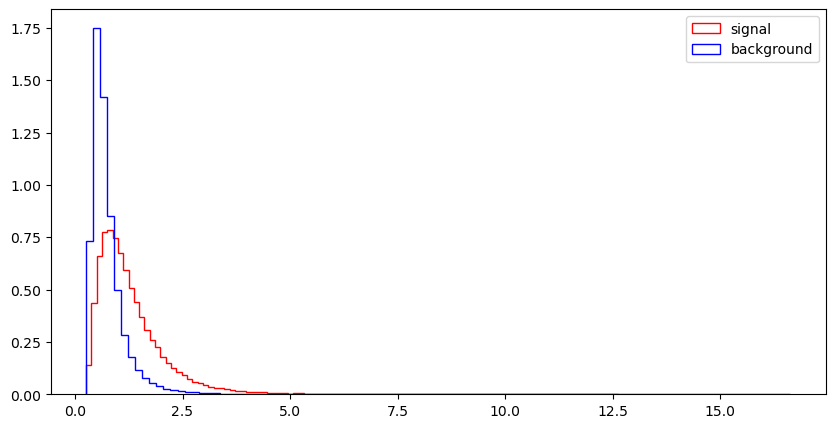

l_1_eta


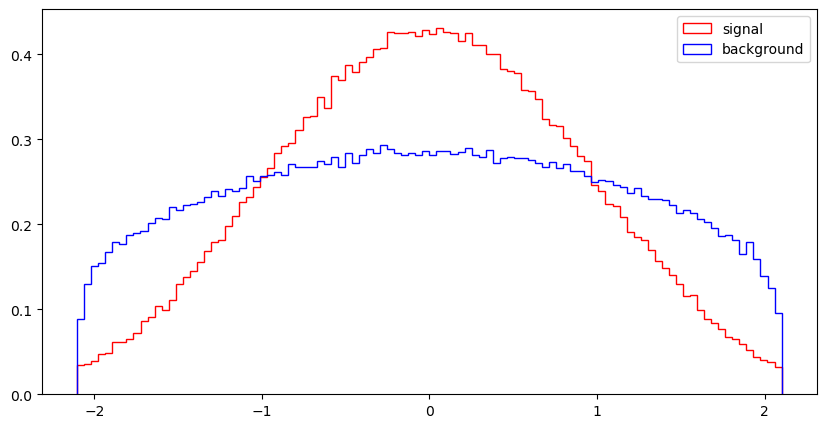

l_1_phi


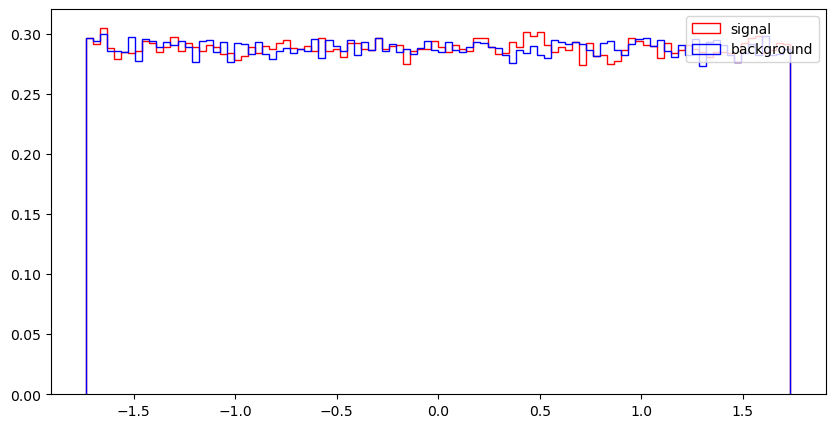

l_2_pT


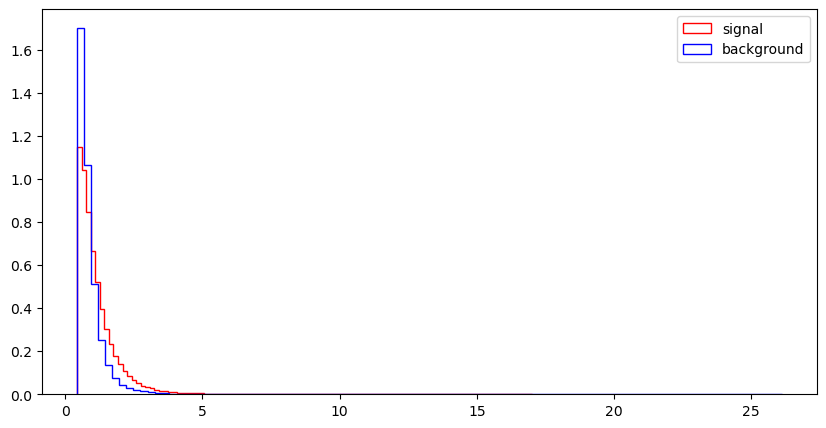

l_2_eta


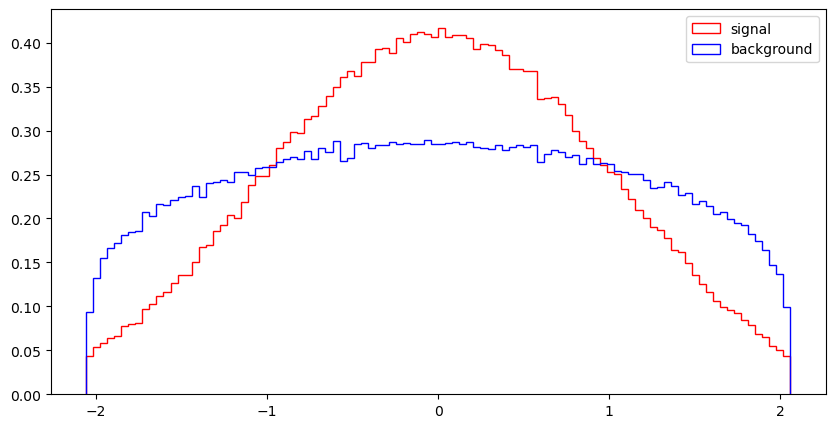

l_2_phi


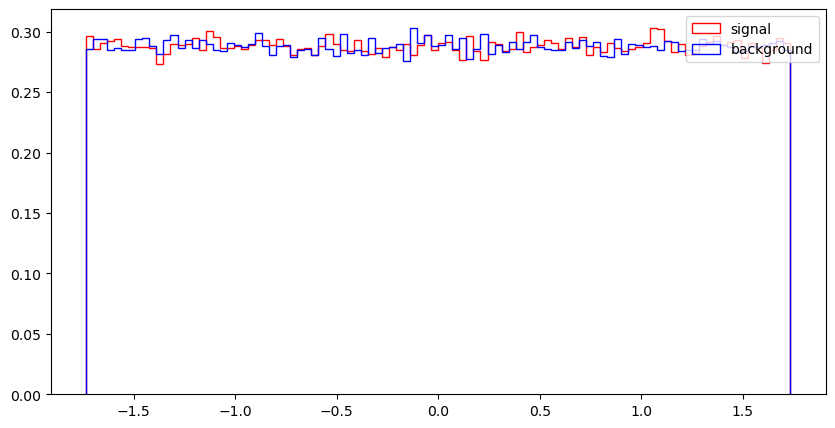

MET


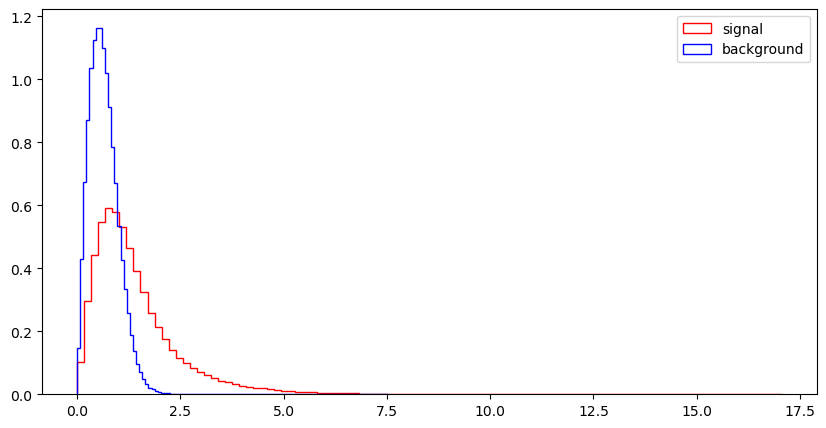

MET_phi


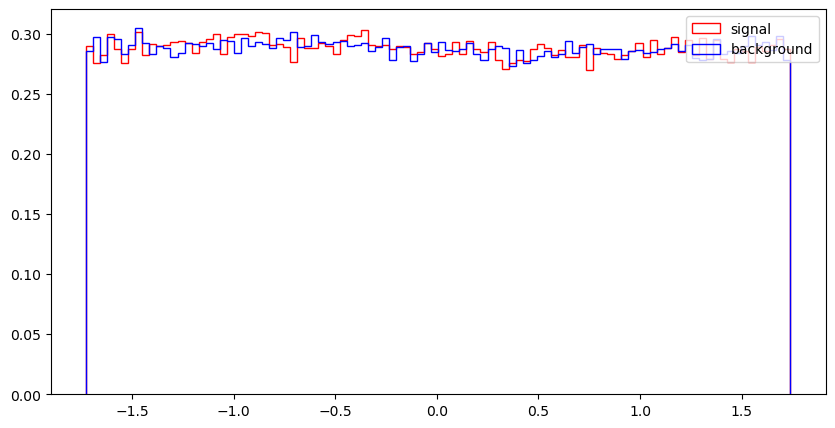

MET_rel


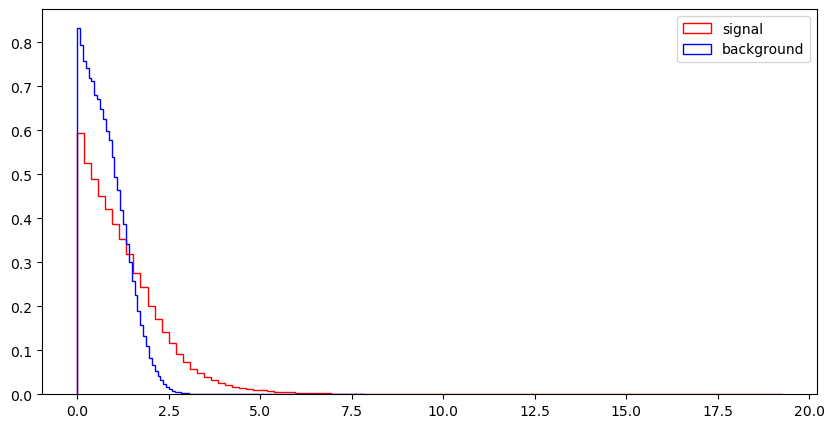

axial_MET


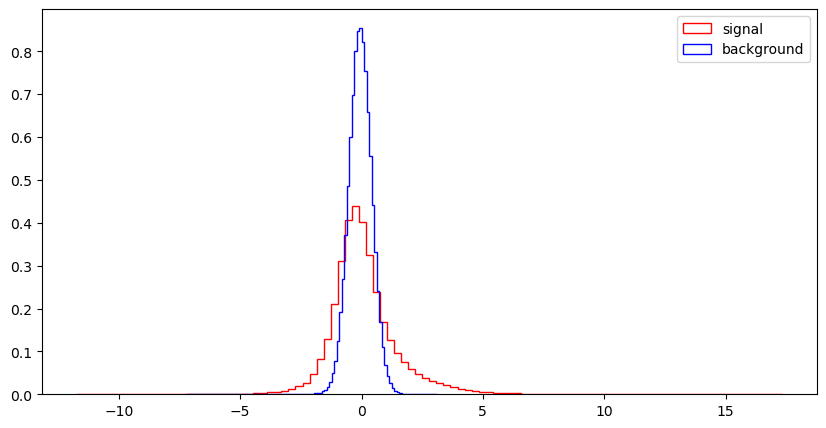

M_R


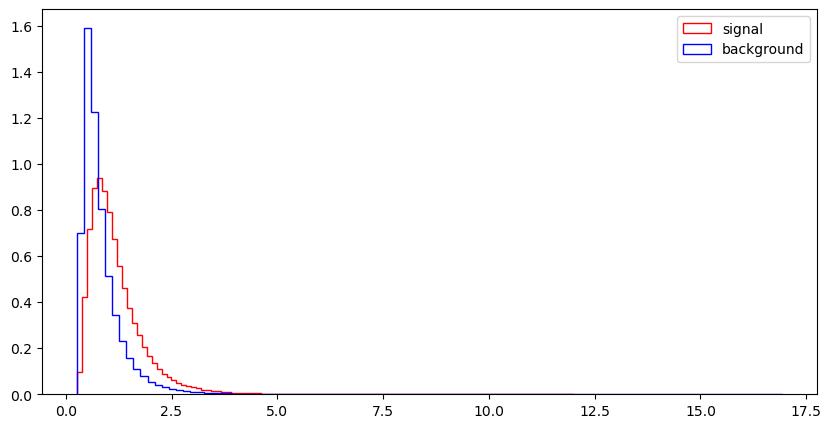

M_TR_2


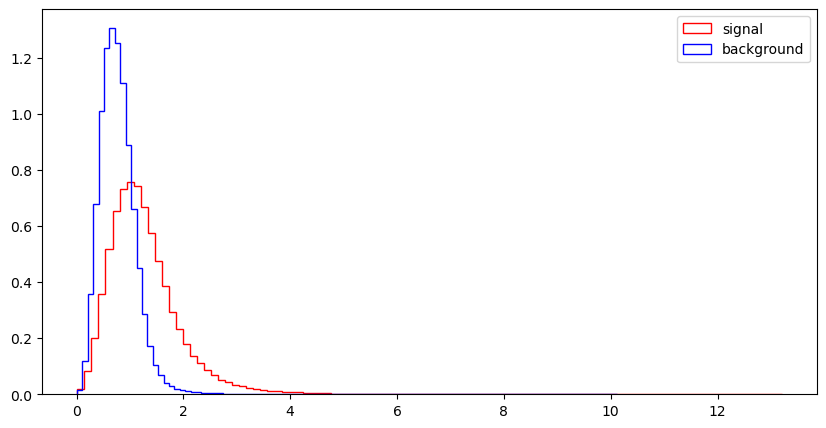

R


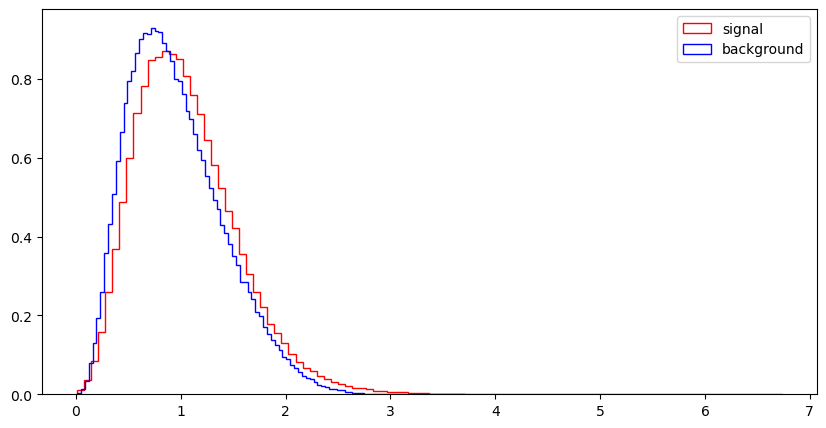

MT2


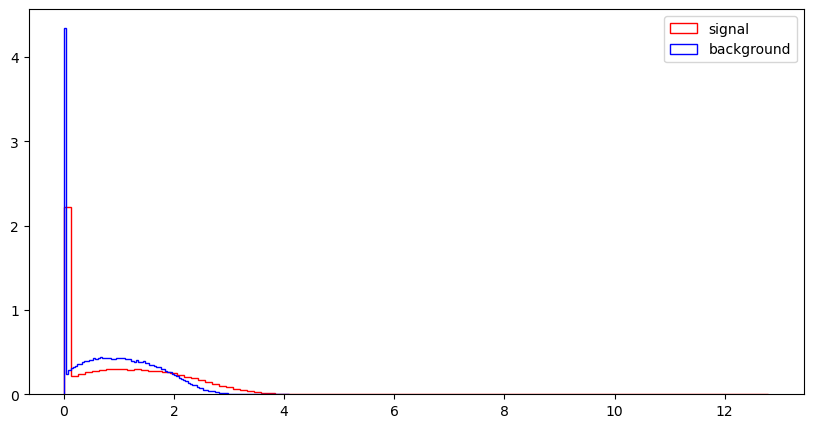

S_R


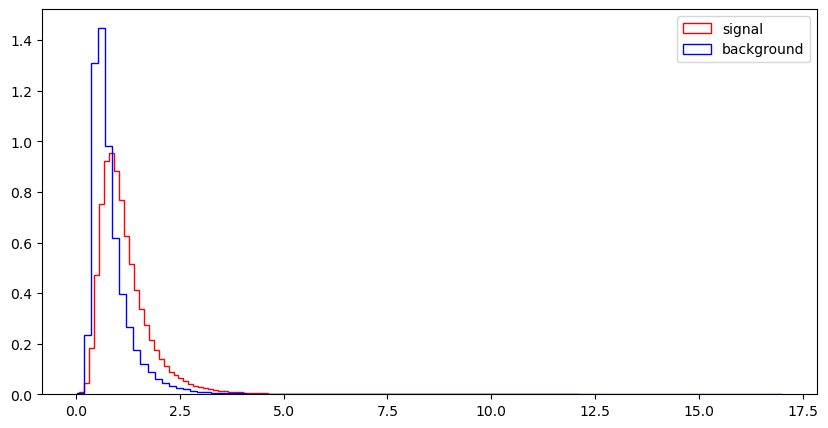

M_Delta_R


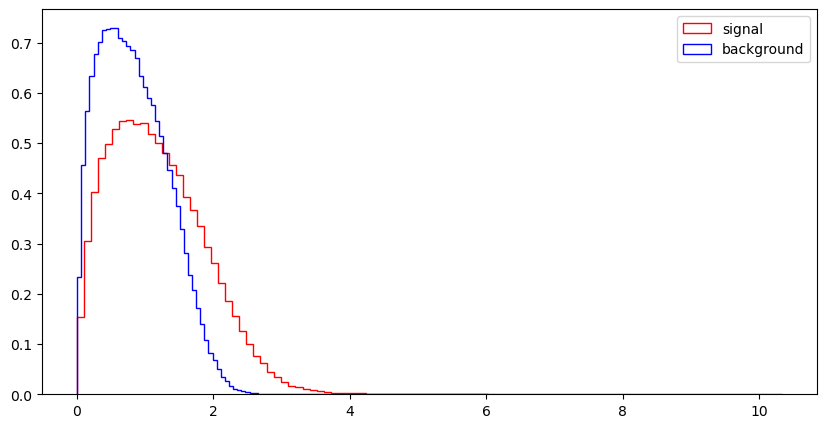

dPhi_r_b


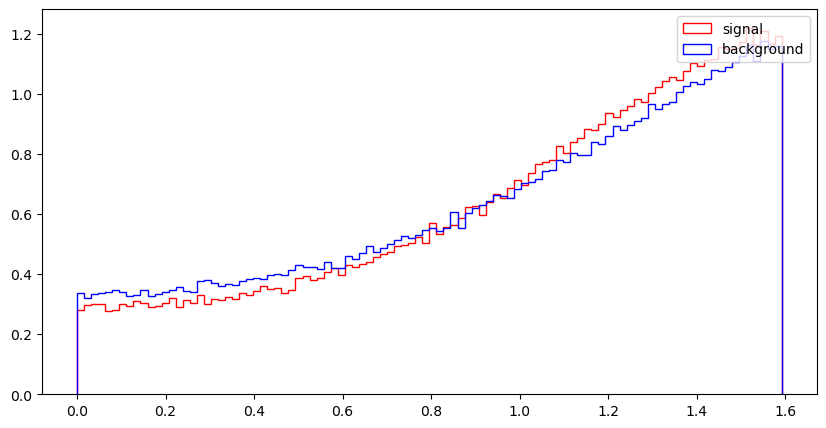

cos_theta_r1


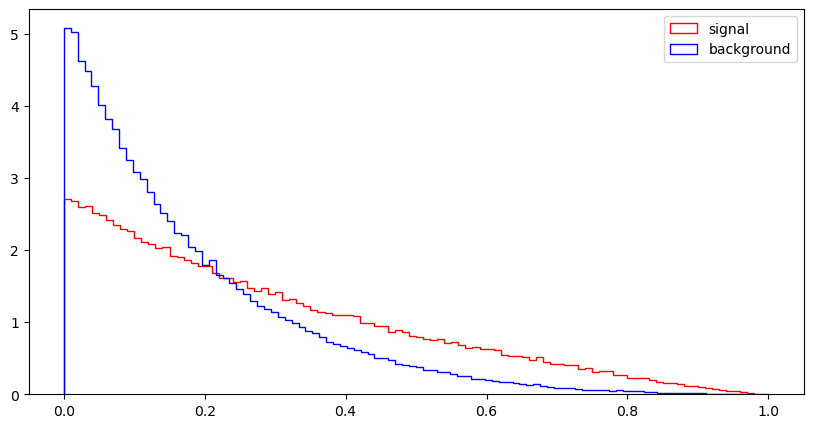

In [45]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

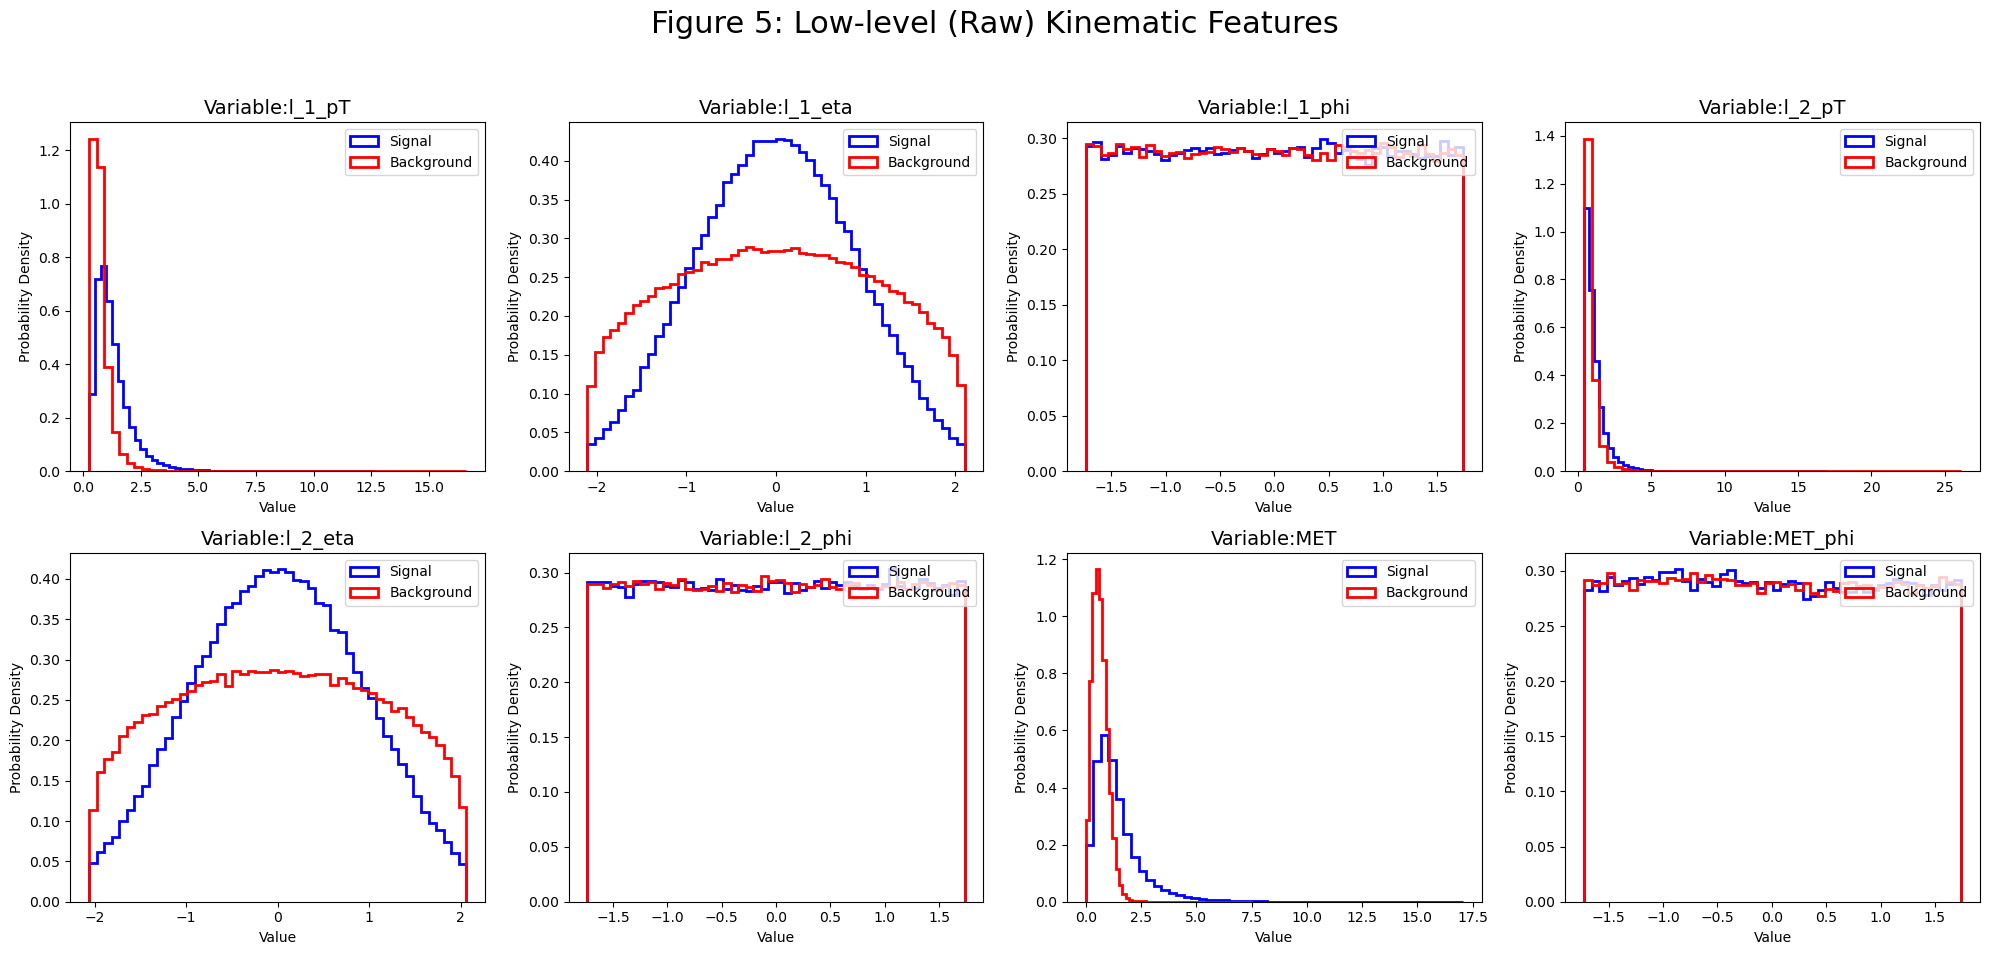

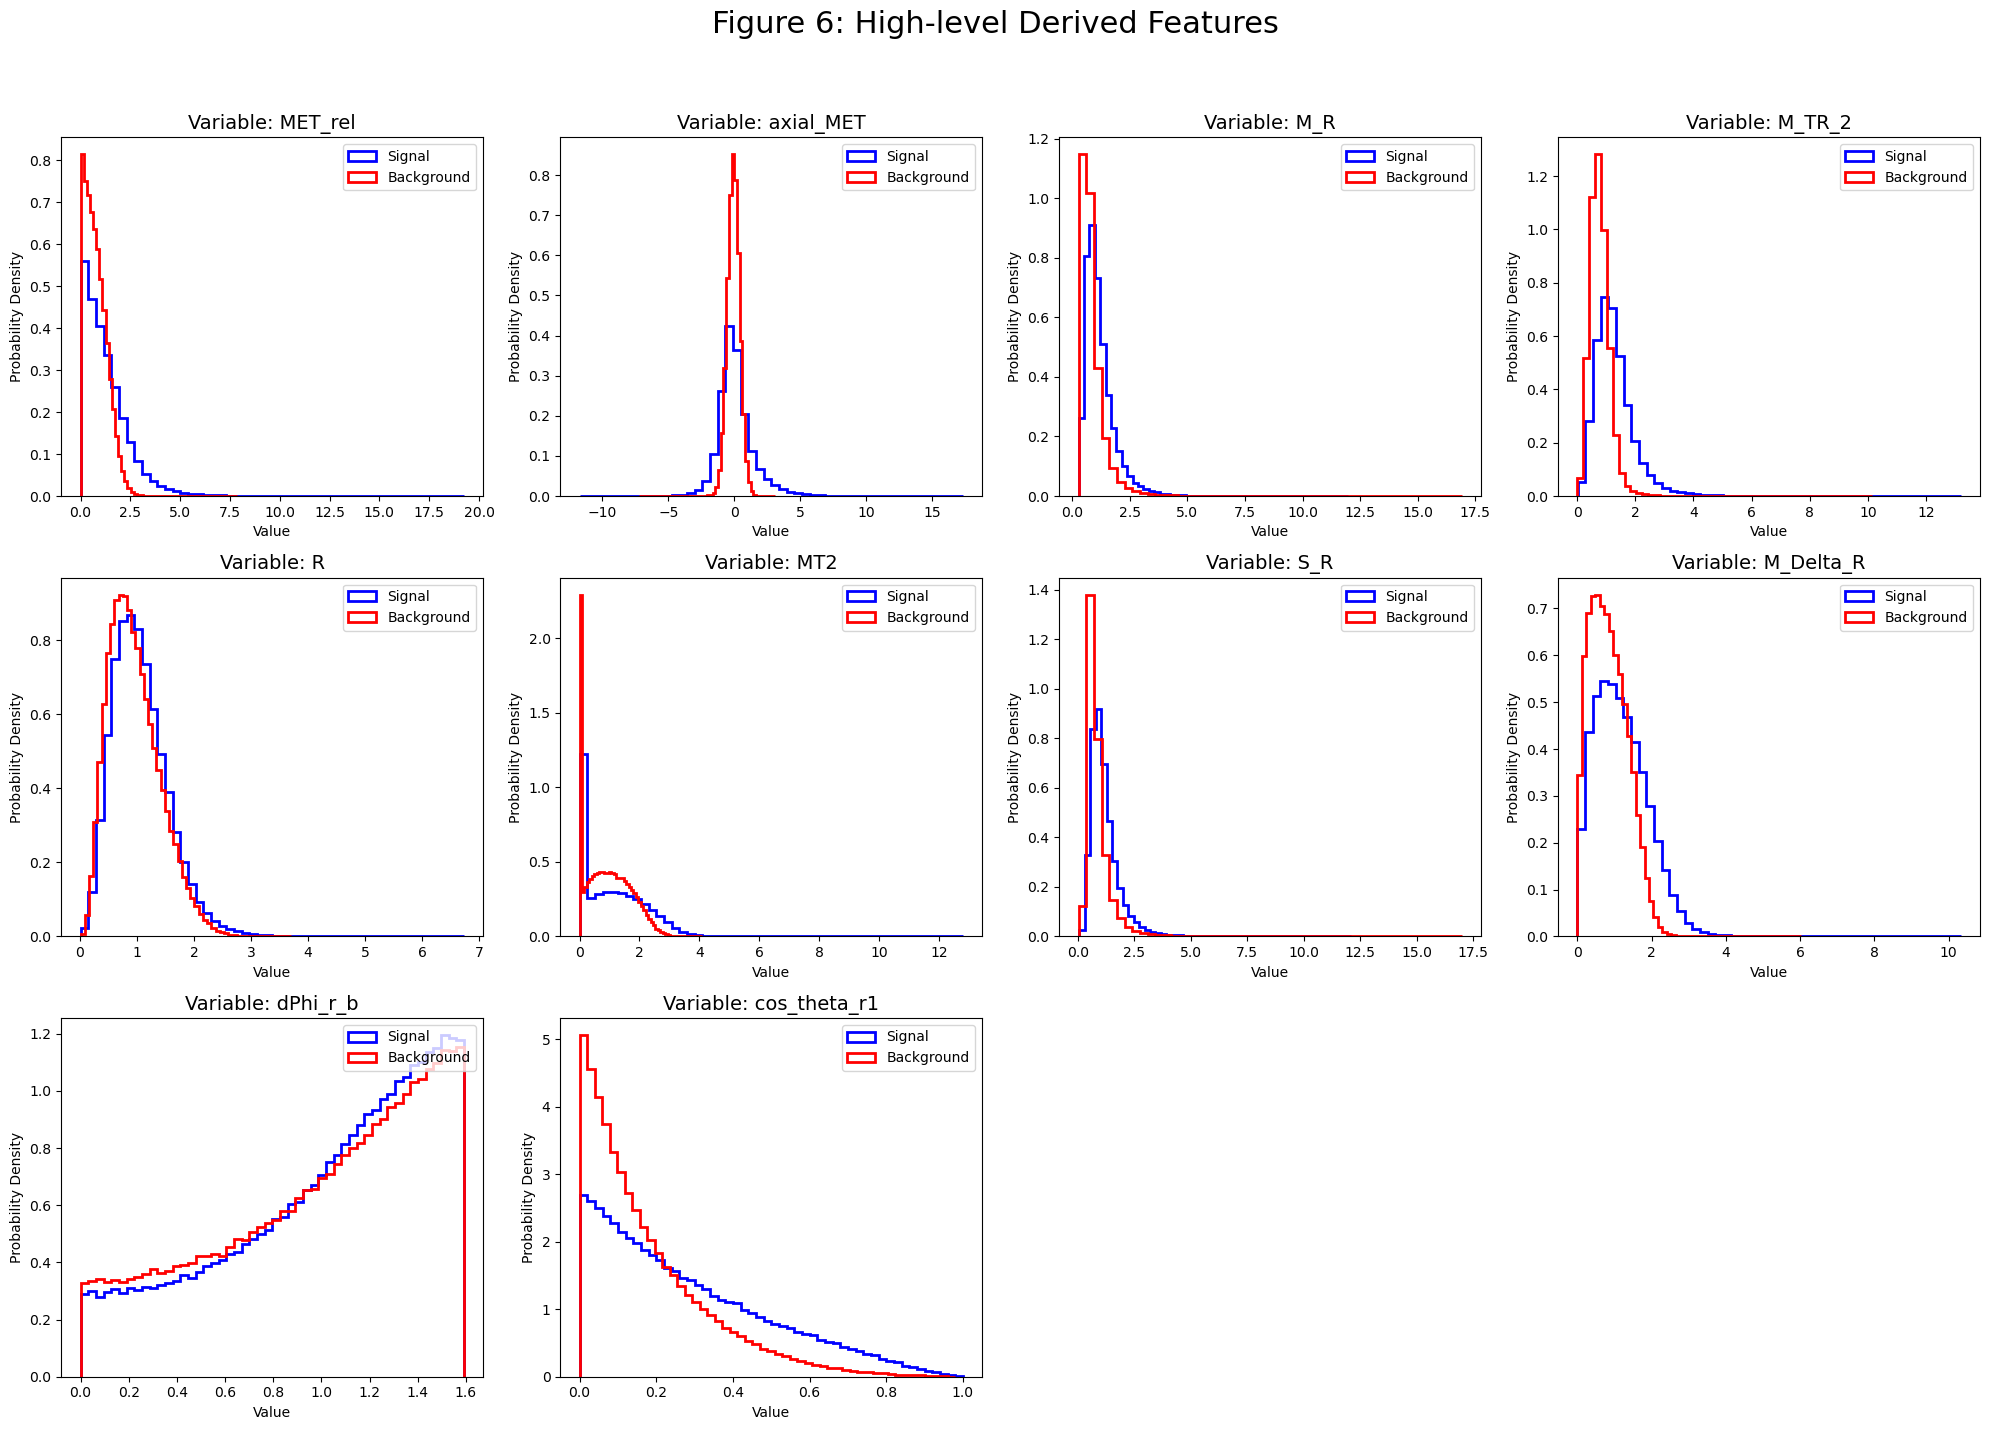

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
#The CSV file has no header so I am defining the names myself.
#signal is the target (1 or 0).The rest are measurements or featurs
VarNames=["signal","l_1_pT","l_1_eta","l_1_phi","l_2_pT","l_2_eta","l_2_phi", ##setting up the columns name
    "MET","MET_phi","MET_rel","axial_MET","M_R","M_TR_2","R","MT2", 
    "S_R","M_Delta_R","dPhi_r_b","cos_theta_r1"]

#I load the smaller version of the dataset to make the code run fast.
#header=None tells pandas that the first row is data, not column names.
df=pd.read_csv("SUSY-small.csv",header=None,names=VarNames)  #loading the data

# We create two separate tables: one for the 'Signal' and one for the 'Background'.
# This makes it very easy to plot them on the same chart later.
sig=df[df['signal']==1]  #splitting the data by category
bkg=df[df['signal']==0]

#raw features for figure 5:
RawNames=["l_1_pT","l_1_eta","l_1_phi","l_2_pT","l_2_eta","l_2_phi","MET","MET_phi"]  #defining the features group

#high level features for figure 6:
FeatureNames=[v for v in VarNames if v not in RawNames and v!='signal']  #list of all names not in rawnames and not the signal label.

fig5,axes5=plt.subplots(nrows=2,ncols=4,figsize=(20,10))  #create a grid with 2 rows and 4 columns(8 total spots)
fig5.suptitle("Figure 5: Low-level (Raw) Kinematic Features",fontsize=22)

axes5=axes5.flatten() #turning the 2D grid into a 1D list 

for i,name in enumerate(RawNames):
    axes5[i].hist(sig[name],bins=50,density=True,color='blue', 
                  histtype='step',linewidth=2,label='Signal')  #createing the thin outline look from the paper
    
    axes5[i].hist(bkg[name],bins=50,density=True,color='red', 
                  histtype='step',linewidth=2,label='Background')
    
    #adding titles and formatting for each small chart:
    axes5[i].set_title(f"Variable:{name}",fontsize=14)
    axes5[i].set_xlabel("Value")
    axes5[i].set_ylabel("Probability Density")
    axes5[i].legend(fontsize=10)

plt.tight_layout(rect=[0,0.03,1,0.95])  #cleaning up the layout
plt.show()
#creating a grid with 3 rows and 4 columns(12 total spots)
fig6,axes6=plt.subplots(nrows=3,ncols=4,figsize=(20,15))
fig6.suptitle("Figure 6: High-level Derived Features",fontsize=22)
axes6=axes6.flatten()


for i, name in enumerate(FeatureNames): #loping through 10 high level features
    axes6[i].hist(sig[name],bins=50,density=True,color='blue', 
                  histtype='step',linewidth=2,label='Signal')
    
    axes6[i].hist(bkg[name],bins=50,density=True,color='red', 
                  histtype='step',linewidth=2,label='Background')
    
    axes6[i].set_title(f"Variable: {name}",fontsize=14)
    axes6[i].set_xlabel("Value")
    axes6[i].set_ylabel("Probability Density")
    axes6[i].legend(fontsize=10)

axes6[10].set_visible(False)  #hiding last two empty boxes
axes6[11].set_visible(False)

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

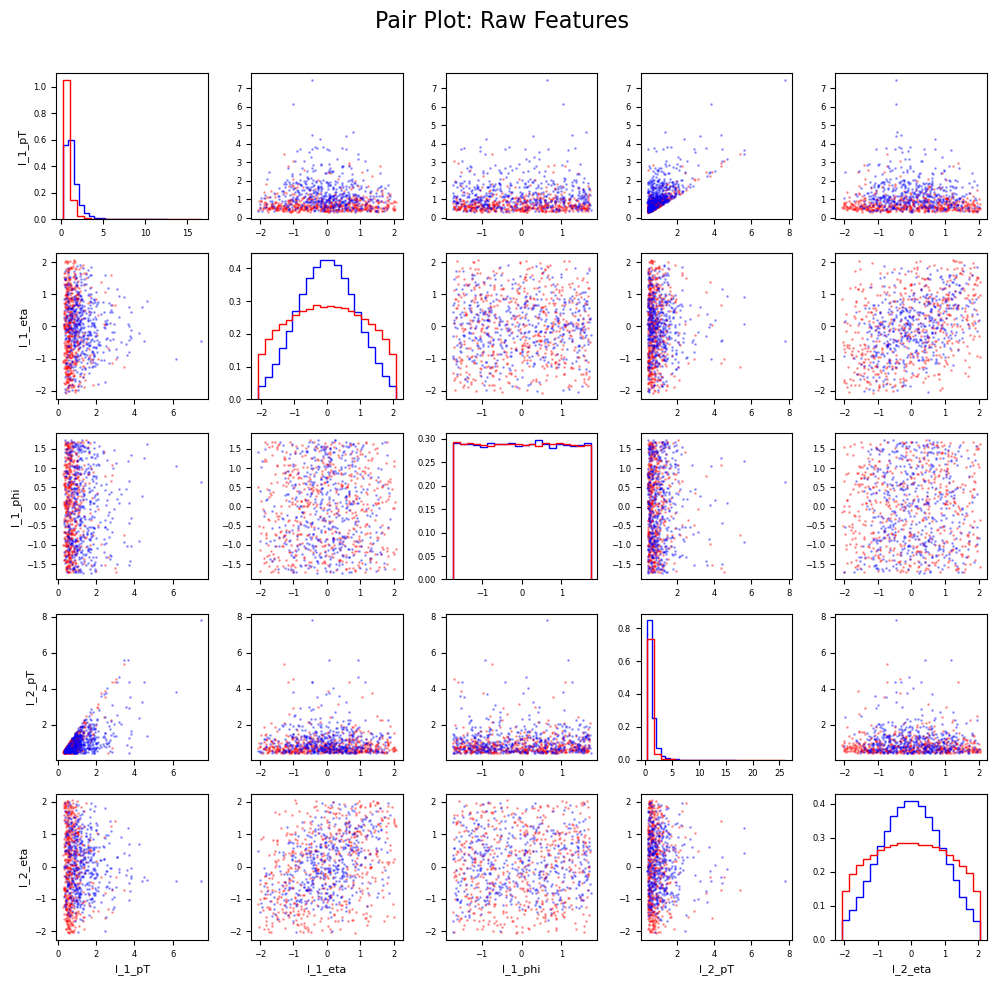

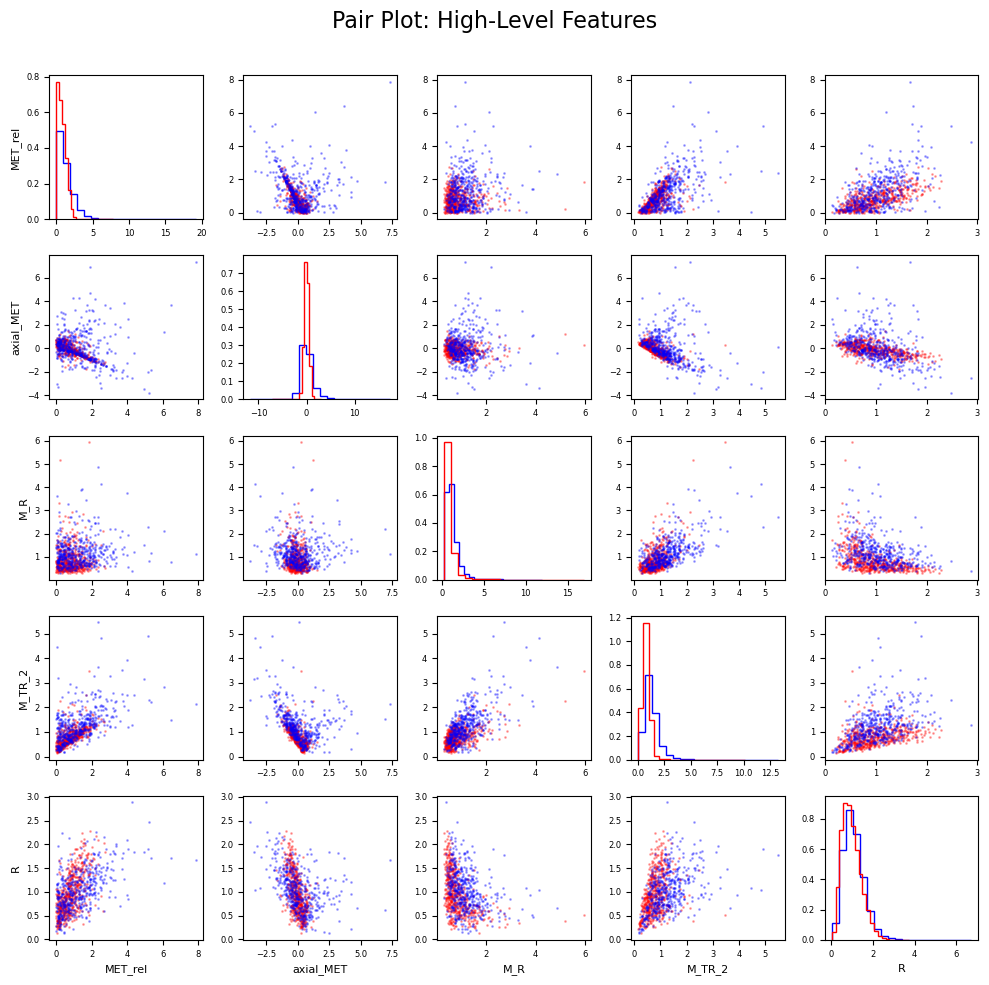

In [45]:
#part a
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#setting up names and load the data
names=["signal","l_1_pT","l_1_eta","l_1_phi","l_2_pT","l_2_eta","l_2_phi","MET","MET_phi","MET_rel","axial_MET","M_R","M_TR_2","R","MT2","S_R","M_Delta_R","dPhi_r_b","cos_theta_r1"]
df=pd.read_csv("SUSY-small.csv",header=None,names=names)
#splitting features into two smaller lists so the pictures are not too crowded
raw_f=names[1:6] #first 5 basic measurements
high_f=names[9:14] #first 5 smart measurements
#defining the plotting function
def make_pair_plot(data,vars,title):
    n=len(vars)
    #creating the grid for our charts
    fig,axes=plt.subplots(n,n,figsize=(n*2,n*2))
    fig.suptitle(title,fontsize=16)
    #picking 1000 random events to make the code run very fast
    sample=data.sample(1000)
    sig=sample[sample['signal']==1]
    bkg=sample[sample['signal']==0]
    for i in range(n):
        for j in range(n):
            ax=axes[i,j]
            if i==j:
                #on the diagonal line I am drawing histograms(one variable)
                ax.hist(data[data['signal']==1][vars[i]],bins=20,density=True,histtype='step',color='blue')
                ax.hist(data[data['signal']==0][vars[i]],bins=20,density=True,histtype='step',color='red')
            else:
                #everywhere else,drawing dots(two variables together)
                ax.scatter(bkg[vars[j]],bkg[vars[i]],s=1,color='red',alpha=0.3)
                ax.scatter(sig[vars[j]],sig[vars[i]],s=1,color='blue',alpha=0.3)
            #only put names on the bottom and left sides
            if i==n-1:ax.set_xlabel(vars[j],fontsize=8)
            if j==0:ax.set_ylabel(vars[i],fontsize=8)
            ax.tick_params(labelsize=6)
    plt.tight_layout(rect=[0,0,1,0.97])
    plt.show()
#running the function for both sets of data
make_pair_plot(df,raw_f,"Pair Plot: Raw Features")
make_pair_plot(df,high_f,"Pair Plot: High-Level Features")

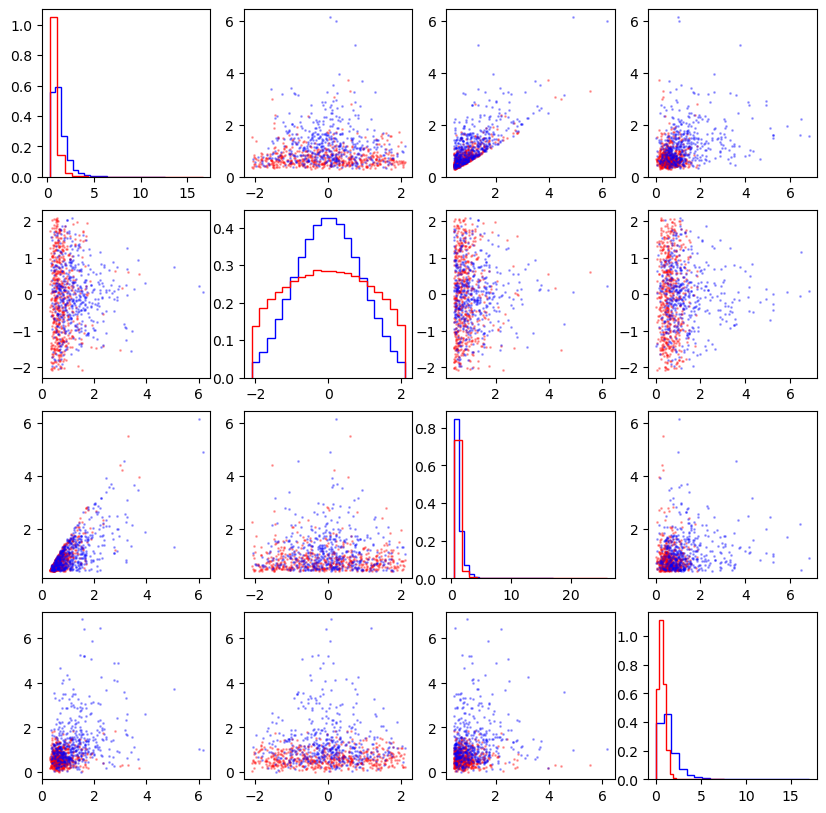

In [49]:
#part b
import pandas as pd
import matplotlib.pyplot as plt
#this function makes a fast grid of plots
cols=["signal","l_1_pT","l_1_eta","l_1_phi","l_2_pT","l_2_eta","l_2_phi","MET","MET_phi","MET_rel","axial_MET","M_R","M_TR_2","R","MT2","S_R","M_Delta_R","dPhi_r_b","cos_theta_r1"]
df=pd.read_csv("SUSY-small.csv",header=None,names=cols)
my_vars=["l_1_pT","l_1_eta","l_2_pT","MET"] #picking a few names to plot so it is not too slow
def fast_pair_plot(data,vars):
    n=len(vars)
    fig,axes=plt.subplots(n,n,figsize=(10,10))
    #picking 1000 random rows so the dots draw very quickly
    sample=data.sample(1000) 
    sig_s=sample[sample['signal']==1] #small group of good events
    bkg_s=sample[sample['signal']==0] #small group of noise events
    for i in range(n):
        for j in range(n):
            ax=axes[i,j]
            if i==j:
                #if row and column are same drawing a line histogram using all data
                ax.hist(data[data['signal']==1][vars[i]],bins=20,density=True,histtype='step',color='blue')
                ax.hist(data[data['signal']==0][vars[i]],bins=20,density=True,histtype='step',color='red')
            else:
                #if row and column are different: draw scatter dots using the 1000-row sample
                ax.scatter(bkg_s[vars[j]],bkg_s[vars[i]],s=1,color='red',alpha=0.3)
                ax.scatter(sig_s[vars[j]],sig_s[vars[i]],s=1,color='blue',alpha=0.3)
    plt.show()
fast_pair_plot(df,my_vars)

In [ ]:
#part b:
#In this part,I focused on making the pair plots draw much faster.Normally,trying to draw a scatter plot with 500000 dots would make the computer freeze or take a very long time. 
#To fix this,I used a trick called subsampling. Instead of using every single row of data for the scatter plots,I told the computer to pick 1000 random rows using the data.sample(1000) command.
#Since 1000 dots are enough to see the general cloud shape of the data,the plots look correct but finish drawing in just a few seconds.

In [ ]:
#part c:
#The high level features seem better for separating signal from background than the low level features.
#For the lowlevel variables,MET and maybe l_1_pT looked more useful than the others.Variables like eta and phi did not seem to separate the two groups very clearly.
#For the high level variables,M_R,M_TR_2,MT2,R,and MET_rel looked the most helpful.Their signal and background distributions looked more different, 
#so they seem better for classification.So in general,the high level observables seem to do a better job than the raw observables.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [55]:
%pip install tabulate --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.9 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [59]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [63]:
#part b
import numpy as np
all_vars=VarNames[1:]
low_vars=RawNames
high_vars=sorted(FeatureNames)
#extracting numpy arrays for each group of variables
X_all=df[all_vars].to_numpy()
cov_all=np.cov(X_all,rowvar=False)
corr_all=np.corrcoef(X_all,rowvar=False)
 
#repeating for low level features only
X_low=df[low_vars].to_numpy()
cov_low=np.cov(X_low,rowvar=False)
corr_low=np.corrcoef(X_low,rowvar=False)
 
#repeating for high level features only
X_high=df[high_vars].to_numpy()
cov_high=np.cov(X_high,rowvar=False)
corr_high=np.corrcoef(X_high,rowvar=False)

In [64]:
#exercise 4.2(c)
#using tabulate to print the matrices in a cleaner table
from IPython.display import HTML,display
import tabulate
 
def format_matrix_table(matrix,columns,decimals=3):
    #building a list of lists table from a matrix with row labels
    table=[]
    for i in range(len(columns)):
        #rounding each entry to specified decimal places
        row=[columns[i]]+[round(matrix[i, j],decimals) for j in range(len(columns))]
        table.append(row)
    return table

In [65]:
#covariance matrix for all observables
print("Covariance Matrix - All Observables")
table=format_matrix_table(cov_all, all_vars, decimals=3)
display(HTML(tabulate.tabulate(table,tablefmt='html',headers=[""]+all_vars)))
 
#correlation matrix for all observables
print("\nCorrelation Matrix - All Observables")
table=format_matrix_table(corr_all,all_vars,decimals=3)
display(HTML(tabulate.tabulate(table,tablefmt='html',headers=[""]+all_vars)))
 
#covariance matrix for low-level features
print("\nCovariance Matrix - Low-Level Features")
table=format_matrix_table(cov_low,low_vars,decimals=3)
display(HTML(tabulate.tabulate(table,tablefmt='html',headers=[""]+low_vars)))
 
#correlation matrix for low-level features
print("\nCorrelation Matrix - Low-Level Features")
table=format_matrix_table(corr_low,low_vars,decimals=3)
display(HTML(tabulate.tabulate(table,tablefmt='html',headers=[""]+low_vars)))
 
#covariance matrix for high-level features
print("\nCovariance Matrix - High-Level Features")
table=format_matrix_table(cov_high,high_vars,decimals=3)
display(HTML(tabulate.tabulate(table,tablefmt='html',headers=[""]+high_vars)))
 
#correlation matrix for high-level features
print("\nCorrelation Matrix - High-Level Features")
table=format_matrix_table(corr_high,high_vars,decimals=3)
display(HTML(tabulate.tabulate(table,tablefmt='html',headers=[""]+high_vars)))

Covariance Matrix - All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001,0.098,-0.01,0.364,0.287,-0.06,-0.012,0.343,0.098,-0.047,0.022
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001,-0.001,-0.001,-0.001,-0.001,0,0,-0.001,-0.001,-0.001,0
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185,0.001,-0.002,0.001,0.001,0,0.001,0.001,0.001,0.001,0
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002,-0.001,0.051,0.325,0.163,-0.099,-0.069,0.322,0.006,-0.004,-0.028
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0,0.001,-0.001,-0.001,0,0,0.001,-0.001,0.001,-0,0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035,0.001,-0.002,0.001,0.001,0.001,0.002,0.001,0.001,-0,0
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.073
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003,-0.005,-0,-0.001,-0.001,-0,0,-0.002,-0.001,-0.002,0
MET_rel,0.098,-0.001,0.001,-0.001,0.001,0.001,0.546,-0.005,0.79,-0.12,0.044,0.302,0.249,0.409,0.082,0.415,0.146,0.055
axial_MET,-0.01,-0.001,-0.002,0.051,-0.001,-0.002,0.154,-0,-0.12,1.005,0.017,-0.185,-0.181,-0.461,-0.041,-0.233,-0.025,-0.054



Correlation Matrix - All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001,0.16,-0.014,0.851,0.723,-0.186,-0.021,0.811,0.229,-0.157,0.165
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001,-0.002,-0.001,-0.001,-0.001,0.001,0,-0.001,-0.002,-0.002,0.002
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184,0.001,-0.002,0.002,0.001,0,0.001,0.002,0.001,0.002,0.001
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002,-0.001,0.078,0.797,0.43,-0.324,-0.123,0.799,0.014,-0.013,-0.217
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0,0.001,-0.001,-0.001,0,0.001,0.002,-0.001,0.001,-0.001,0.001
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035,0.002,-0.002,0.001,0.001,0.001,0.003,0.001,0.002,-0.001,0
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003,0.704,0.176,0.264,0.72,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1,-0.005,-0,-0.002,-0.002,-0,0,-0.003,-0.001,-0.004,0.001
MET_rel,0.16,-0.002,0.001,-0.001,0.001,0.002,0.704,-0.005,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.014,-0.001,-0.002,0.078,-0.001,-0.002,0.176,-0,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272



Covariance Matrix - Low-Level Features


...

,l_1_pT,l_1_eta,l_2_pT,l_2_eta
l_1_pT,1,-0.001,0.684,-0.001
l_1_eta,-0.001,1,-0,0.406
l_2_pT,0.684,-0,1,-0.001
l_2_eta,-0.001,0.406,-0.001,1



Covariance Matrix - High-Level Features


,MET_rel,MT2,M_Delta_R,M_R,M_TR_2,R,S_R,axial_MET,cos_theta_r1,dPhi_r_b
MET_rel,0.79,0.409,0.415,0.044,0.302,0.249,0.082,-0.12,0.055,0.146
MT2,0.409,0.738,0.433,-0.037,0.189,0.232,-0.011,-0.461,0.045,0.021
M_Delta_R,0.415,0.433,0.389,0.074,0.242,0.165,0.096,-0.233,0.039,0.042
M_R,0.044,-0.037,0.074,0.392,0.21,-0.113,0.38,0.017,-0.014,-0.029
M_TR_2,0.302,0.189,0.242,0.21,0.338,0.104,0.228,-0.185,0.052,0.058
R,0.249,0.232,0.165,-0.113,0.104,0.222,-0.083,-0.181,0.058,0.087
S_R,0.082,-0.011,0.096,0.38,0.228,-0.083,0.382,-0.041,-0.01,-0.003
axial_MET,-0.12,-0.461,-0.233,0.017,-0.185,-0.181,-0.041,1.005,-0.054,-0.025
cos_theta_r1,0.055,0.045,0.039,-0.014,0.052,0.058,-0.01,-0.054,0.039,0.009
dPhi_r_b,0.146,0.021,0.042,-0.029,0.058,0.087,-0.003,-0.025,0.009,0.19



Correlation Matrix - High-Level Features


,MET_rel,MT2,M_Delta_R,M_R,M_TR_2,R,S_R,axial_MET,cos_theta_r1,dPhi_r_b
MET_rel,1,0.535,0.748,0.078,0.584,0.595,0.15,-0.134,0.316,0.378
MT2,0.535,1,0.809,-0.068,0.379,0.574,-0.021,-0.535,0.264,0.056
M_Delta_R,0.748,0.809,1,0.189,0.668,0.564,0.249,-0.373,0.319,0.155
M_R,0.078,-0.068,0.189,1,0.577,-0.383,0.981,0.027,-0.116,-0.106
M_TR_2,0.584,0.379,0.668,0.577,1,0.38,0.635,-0.317,0.451,0.229
R,0.595,0.574,0.564,-0.383,0.38,1,-0.287,-0.383,0.627,0.424
S_R,0.15,-0.021,0.249,0.981,0.635,-0.287,1,-0.067,-0.085,-0.013
axial_MET,-0.134,-0.535,-0.373,0.027,-0.317,-0.383,-0.067,1,-0.272,-0.057
cos_theta_r1,0.316,0.264,0.319,-0.116,0.451,0.627,-0.085,-0.272,1,0.106
dPhi_r_b,0.378,0.056,0.155,-0.106,0.229,0.424,-0.013,-0.057,0.106,1


In [67]:
#part d
#wrapping parts b and c into a single reusable function
#takeing a dataframe list of column names and optional decimals
 
def show_cov_corr_tables(df,columns,decimals=3):
    #computing covariance and correlation matrices for the given columns and embedding them as HTML tables in the notebook.
 
    #extracting selected columns as a numpy array:
    X=df[columns].to_numpy()
 
    #computing covariance and correlation matrices
    cov_mat=np.cov(X,rowvar=False)
    corr_mat=np.corrcoef(X,rowvar=False)
 
    #building and displaying the covariance table
    print("Covariance Matrix")
    cov_table=format_matrix_table(cov_mat,columns,decimals=decimals)
    display(HTML(tabulate.tabulate(cov_table,tablefmt='html',headers=[""]+columns)))
 
    #building and displaying the correlation table
    print("\nCorrelation Matrix")
    corr_table=format_matrix_table(corr_mat,columns,decimals=decimals)
    display(HTML(tabulate.tabulate(corr_table,tablefmt='html',headers=[""]+columns)))
 
    return cov_mat, corr_mat

In [69]:
#testing the function on each group
print("All Observables")
cov_all,corr_all=show_cov_corr_tables(df,all_vars,decimals=3)
 
print("\n Low-Level Features")
cov_low,corr_low=show_cov_corr_tables(df,low_vars,decimals=3)
 
print("\n High-Level Features")
cov_high,corr_high=show_cov_corr_tables(df,high_vars,decimals=3)

All Observables
Covariance Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001,0.098,-0.01,0.364,0.287,-0.06,-0.012,0.343,0.098,-0.047,0.022
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001,-0.001,-0.001,-0.001,-0.001,0,0,-0.001,-0.001,-0.001,0
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185,0.001,-0.002,0.001,0.001,0,0.001,0.001,0.001,0.001,0
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002,-0.001,0.051,0.325,0.163,-0.099,-0.069,0.322,0.006,-0.004,-0.028
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0,0.001,-0.001,-0.001,0,0,0.001,-0.001,0.001,-0,0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035,0.001,-0.002,0.001,0.001,0.001,0.002,0.001,0.001,-0,0
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.073
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003,-0.005,-0,-0.001,-0.001,-0,0,-0.002,-0.001,-0.002,0
MET_rel,0.098,-0.001,0.001,-0.001,0.001,0.001,0.546,-0.005,0.79,-0.12,0.044,0.302,0.249,0.409,0.082,0.415,0.146,0.055
axial_MET,-0.01,-0.001,-0.002,0.051,-0.001,-0.002,0.154,-0,-0.12,1.005,0.017,-0.185,-0.181,-0.461,-0.041,-0.233,-0.025,-0.054



Correlation Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001,0.16,-0.014,0.851,0.723,-0.186,-0.021,0.811,0.229,-0.157,0.165
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001,-0.002,-0.001,-0.001,-0.001,0.001,0,-0.001,-0.002,-0.002,0.002
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184,0.001,-0.002,0.002,0.001,0,0.001,0.002,0.001,0.002,0.001
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002,-0.001,0.078,0.797,0.43,-0.324,-0.123,0.799,0.014,-0.013,-0.217
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0,0.001,-0.001,-0.001,0,0.001,0.002,-0.001,0.001,-0.001,0.001
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035,0.002,-0.002,0.001,0.001,0.001,0.003,0.001,0.002,-0.001,0
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003,0.704,0.176,0.264,0.72,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1,-0.005,-0,-0.002,-0.002,-0,0,-0.003,-0.001,-0.004,0.001
MET_rel,0.16,-0.002,0.001,-0.001,0.001,0.002,0.704,-0.005,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.014,-0.001,-0.002,0.078,-0.001,-0.002,0.176,-0,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272



 Low-Level Features
Covariance Matrix


...

,l_1_pT,l_1_eta,l_2_pT,l_2_eta
l_1_pT,1,-0.001,0.684,-0.001
l_1_eta,-0.001,1,-0,0.406
l_2_pT,0.684,-0,1,-0.001
l_2_eta,-0.001,0.406,-0.001,1



 High-Level Features
Covariance Matrix


,MET_rel,MT2,M_Delta_R,M_R,M_TR_2,R,S_R,axial_MET,cos_theta_r1,dPhi_r_b
MET_rel,0.79,0.409,0.415,0.044,0.302,0.249,0.082,-0.12,0.055,0.146
MT2,0.409,0.738,0.433,-0.037,0.189,0.232,-0.011,-0.461,0.045,0.021
M_Delta_R,0.415,0.433,0.389,0.074,0.242,0.165,0.096,-0.233,0.039,0.042
M_R,0.044,-0.037,0.074,0.392,0.21,-0.113,0.38,0.017,-0.014,-0.029
M_TR_2,0.302,0.189,0.242,0.21,0.338,0.104,0.228,-0.185,0.052,0.058
R,0.249,0.232,0.165,-0.113,0.104,0.222,-0.083,-0.181,0.058,0.087
S_R,0.082,-0.011,0.096,0.38,0.228,-0.083,0.382,-0.041,-0.01,-0.003
axial_MET,-0.12,-0.461,-0.233,0.017,-0.185,-0.181,-0.041,1.005,-0.054,-0.025
cos_theta_r1,0.055,0.045,0.039,-0.014,0.052,0.058,-0.01,-0.054,0.039,0.009
dPhi_r_b,0.146,0.021,0.042,-0.029,0.058,0.087,-0.003,-0.025,0.009,0.19



Correlation Matrix


,MET_rel,MT2,M_Delta_R,M_R,M_TR_2,R,S_R,axial_MET,cos_theta_r1,dPhi_r_b
MET_rel,1,0.535,0.748,0.078,0.584,0.595,0.15,-0.134,0.316,0.378
MT2,0.535,1,0.809,-0.068,0.379,0.574,-0.021,-0.535,0.264,0.056
M_Delta_R,0.748,0.809,1,0.189,0.668,0.564,0.249,-0.373,0.319,0.155
M_R,0.078,-0.068,0.189,1,0.577,-0.383,0.981,0.027,-0.116,-0.106
M_TR_2,0.584,0.379,0.668,0.577,1,0.38,0.635,-0.317,0.451,0.229
R,0.595,0.574,0.564,-0.383,0.38,1,-0.287,-0.383,0.627,0.424
S_R,0.15,-0.021,0.249,0.981,0.635,-0.287,1,-0.067,-0.085,-0.013
axial_MET,-0.134,-0.535,-0.373,0.027,-0.317,-0.383,-0.067,1,-0.272,-0.057
cos_theta_r1,0.316,0.264,0.319,-0.116,0.451,0.627,-0.085,-0.272,1,0.106
dPhi_r_b,0.378,0.056,0.155,-0.106,0.229,0.424,-0.013,-0.057,0.106,1


Hint: Example code for embedding a `tabulate` table into a notebook:

In [ ]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 